# Inspecting a fitted model

This notebook loads a model fitted in `1_fit_model.ipynb` and produces science maps and fit quality diagnostics. To change which line to inspect, edit `LINE` in `config.py`.

In [ ]:
import cmasher as cmr  # noqa: F401
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotdrip  # noqa: F401
import numpy as np
from config import CFG, MODEL_PATH, load_flame
from lvm_tools.utils.mask import mask_near_points
from matplotdrip import colormaps  # noqa: F401
from spectracles import SpatialDataGeneric, load_model

jax.config.update("jax_enable_x64", True)
plt.style.use("matplotdrip.custom")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "text.usetex": False,
        "mathtext.default": "regular",
    }
)

print(f"Inspecting: {CFG.label} ({CFG.lambda_centre} Å)")

Inspecting: [NII] 6583 (6583.45 Å)


In [2]:
fd = load_flame()
model = load_model(MODEL_PATH)
locked = model.get_locked_model()
print(f"Model loaded from {MODEL_PATH}")

Model loaded from models/nii.model


/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: 

## Science maps

Evaluate the three spatial fields (amplitude, velocity, velocity dispersion) on a dense grid for visualisation.

In [ ]:
# Build dense spatial grid
Ng = 500
α_dense_ = jnp.linspace(fd.α.min(), fd.α.max(), Ng)
δ_dense_ = jnp.linspace(fd.δ.min(), fd.δ.max(), Ng)
α_dense, δ_dense = [x.flatten() for x in np.meshgrid(α_dense_, δ_dense_)]
αδ_dense = SpatialDataGeneric(x=α_dense, y=δ_dense, idx=np.arange(len(α_dense)))

# Footprint mask: NaN out pixels far from any data point
footprint = mask_near_points(
    xgrid=α_dense_, ygrid=δ_dense_, xpoints=fd.α, ypoints=fd.δ, threshold=0.1
)

# Evaluate fields, masking outside the data footprint
A_field = np.where(
    footprint,
    fd.predict_flux(locked.line.A(αδ_dense).reshape((Ng, Ng))) / 1e-12,
    np.nan,
)
v_field = np.where(footprint, locked.line.v(αδ_dense).reshape((Ng, Ng)), np.nan)
vσ_field = np.where(footprint, locked.line.vσ(αδ_dense).reshape((Ng, Ng)), np.nan)

# Spatial extent in real coordinates
α_data = fd.predict_α(α_dense_)
δ_data = fd.predict_δ(δ_dense_)
extent = [α_data.min(), α_data.max(), δ_data.min(), δ_data.max()]

2026-03-15 15:51:55.167059: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2


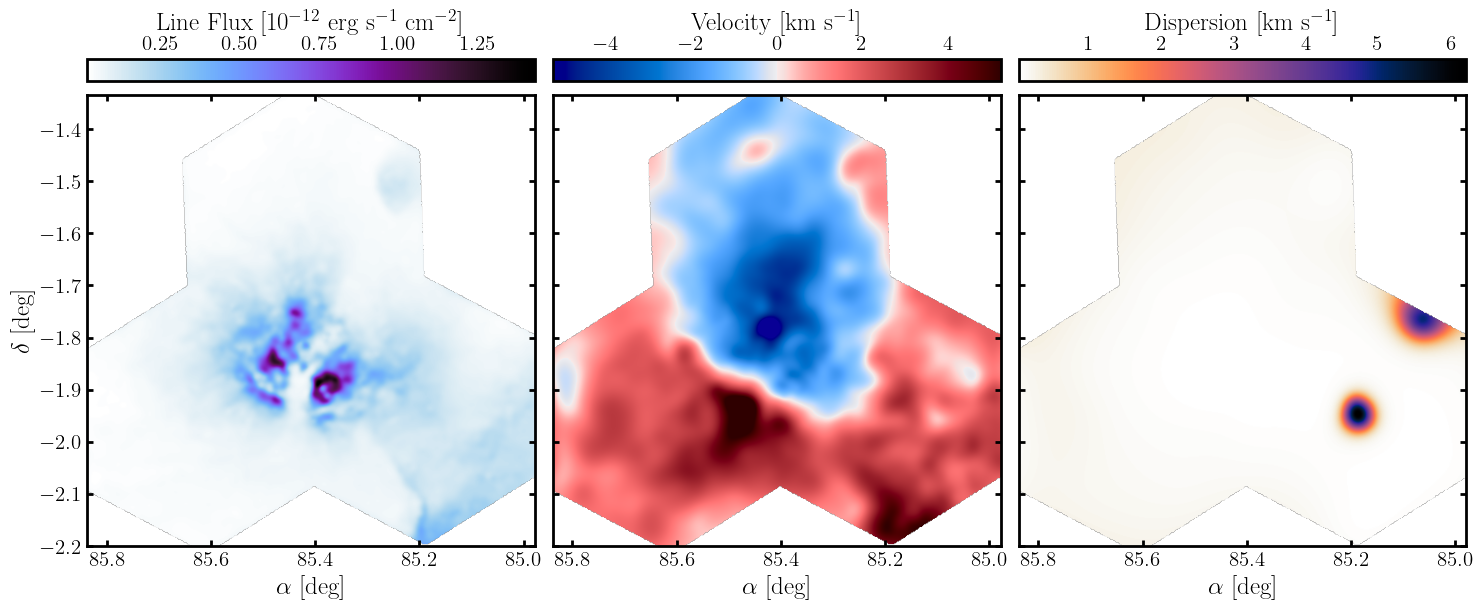

In [ ]:
imshow_kwargs = dict(origin="lower", extent=extent, rasterized=True)
cbar_kwargs = dict(orientation="horizontal", location="top", pad=0.03)

fig, axes = plt.subplots(
    1, 3, figsize=(18, 6), dpi=100, layout="compressed", sharex=True, sharey=True
)

# Amplitude
im0 = axes[0].imshow(A_field, cmap="cmr.voltage_r", **imshow_kwargs)
fig.colorbar(
    im0,
    ax=axes[0],
    label=r"Line Flux [10$^{-12}$ erg s$^{-1}$ cm$^{-2}$]",
    **cbar_kwargs,
)

# Velocity
v_vmax = np.nanpercentile(np.abs(v_field), 99)
im1 = axes[1].imshow(
    v_field, cmap="red_white_blue_r", vmin=-v_vmax, vmax=v_vmax, **imshow_kwargs
)
fig.colorbar(im1, ax=axes[1], label=r"Velocity [km s$^{-1}$]", **cbar_kwargs)

# Velocity dispersion
im2 = axes[2].imshow(vσ_field, cmap="cmr.torch_r", **imshow_kwargs)
fig.colorbar(im2, ax=axes[2], label=r"Dispersion [km s$^{-1}$]", **cbar_kwargs)

axes[-1].set_xlim(axes[-1].get_xlim()[::-1])
for ax in axes:
    ax.set_xlabel(r"$\alpha$ [deg]")
    ax.set_aspect("equal")
axes[0].set_ylabel(r"$\delta$ [deg]")
plt.show()

## Calibration factors

Per-tile flux calibration and per-IFU wavelength calibration corrections learned by the model.

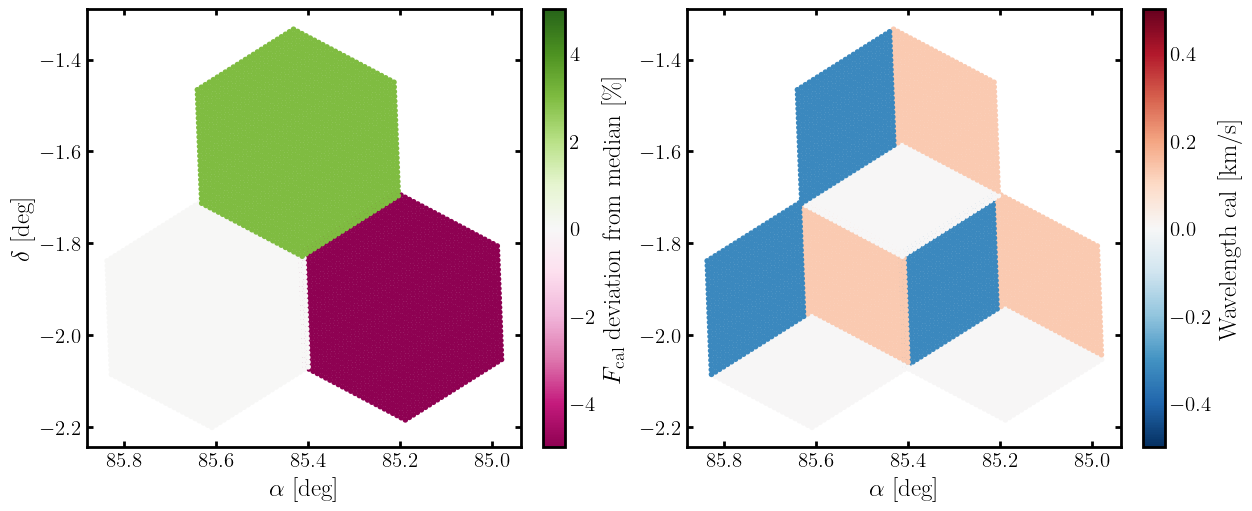

In [13]:
f_cal = locked.flux_cal(fd.αδ_data)
f_cal_pct = 100 * (f_cal / np.median(f_cal) - 1)
v_cal = locked.line.v_cal(fd.αδ_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), layout="compressed")

sc1 = ax1.scatter(
    fd.predict_α(fd.α),
    fd.predict_δ(fd.δ),
    c=f_cal_pct,
    s=16,
    cmap="PiYG",
    vmin=-5,
    vmax=5,
    edgecolor="none",
)
ax1.set_xlim(ax1.get_xlim()[::-1])
ax1.set_aspect("equal")
ax1.set_xlabel(r"$\alpha$ [deg]")
ax1.set_ylabel(r"$\delta$ [deg]")
fig.colorbar(sc1, ax=ax1, label=r"$F_\mathrm{cal}$ deviation from median [\%]")

sc2 = ax2.scatter(
    fd.predict_α(fd.α),
    fd.predict_δ(fd.δ),
    c=v_cal,
    s=16,
    cmap="RdBu_r",
    edgecolor="none",
    vmin=-0.5,
    vmax=0.5,
)
ax2.set_xlim(ax2.get_xlim()[::-1])
ax2.set_aspect("equal")
ax2.set_xlabel(r"$\alpha$ [deg]")
fig.colorbar(sc2, ax=ax2, label="Wavelength cal [km/s]")
plt.show()

## Fit quality: spectra overlays

Data vs model for random spaxels. The model (colour) should trace the data (black) closely.

2026-03-15 15:51:57.669887: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2
2026-03-15 15:51:58.630370: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self

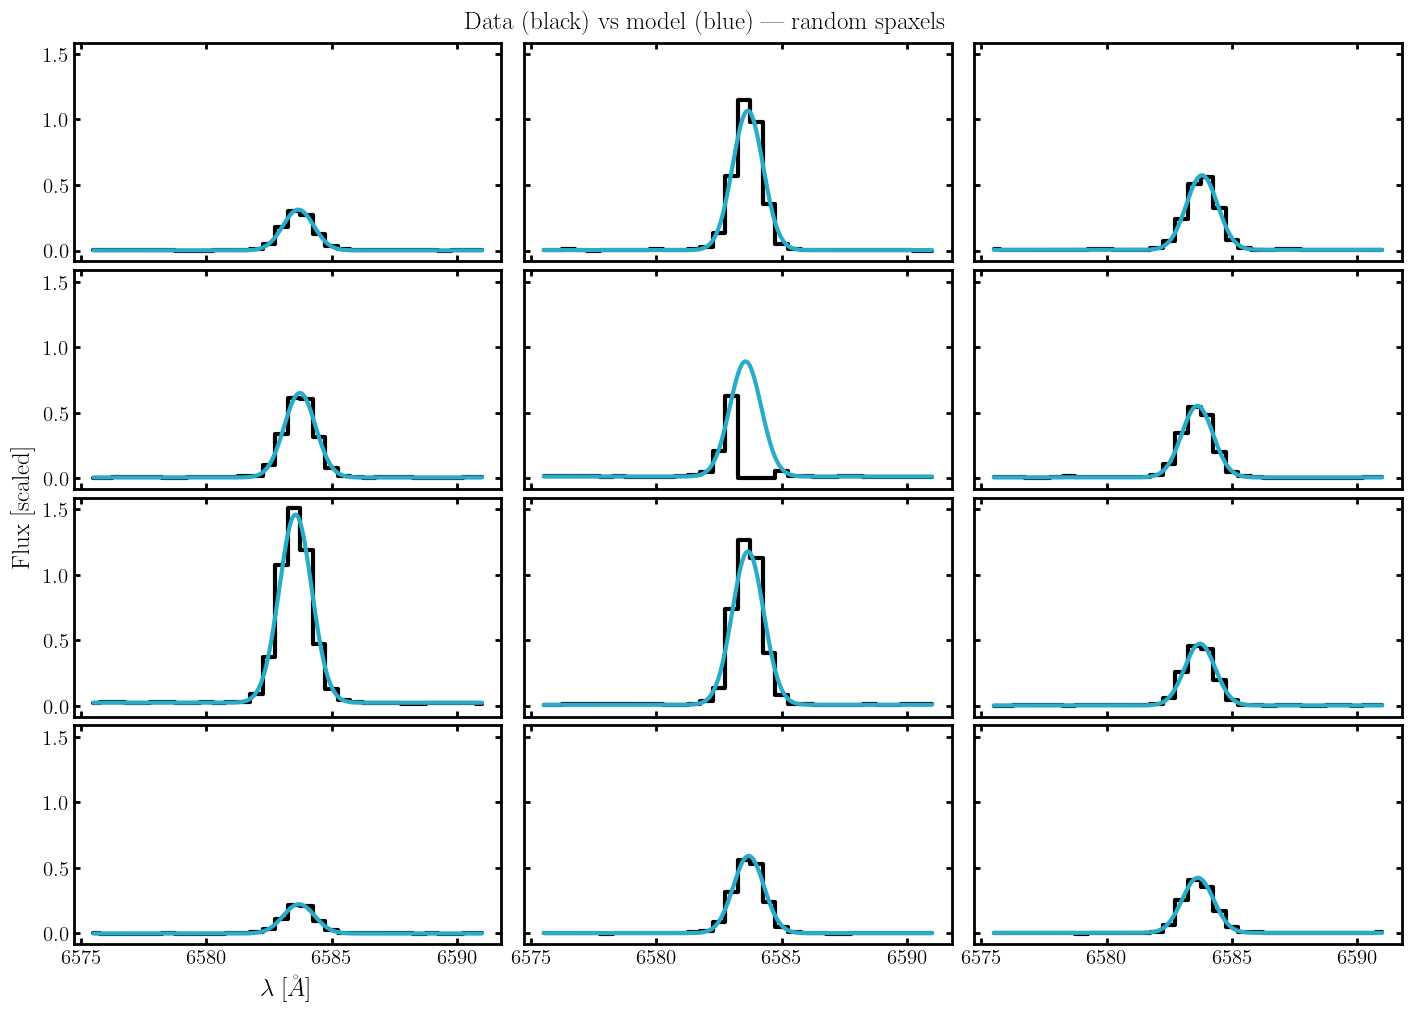

/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_project/lvm_spectral_spatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:758: 

In [ ]:
# Model predictions on dense λ grid for smooth curves
λ_dense = jnp.linspace(fd.λ.min(), fd.λ.max(), 500)
pred_λ_dense = jax.vmap(locked, in_axes=(0, None))(λ_dense, fd.αδ_data)

# Model predictions at data wavelengths for residuals
pred_data = jax.vmap(locked, in_axes=(0, None))(fd.λ, fd.αδ_data)

rng = np.random.default_rng(0)
spax_inds = rng.choice(len(fd.spaxel_idx), size=12, replace=False)

fig, axes = plt.subplots(
    4, 3, figsize=(14, 10), sharex=True, sharey=True, layout="compressed"
)
for i, ax in enumerate(axes.flat):
    si = spax_inds[i]
    ax.step(fd.λ, fd.flux[:, si], c="k", where="mid", zorder=-2)
    ax.plot(λ_dense, pred_λ_dense[:, si], c="C0")
axes[-1, 0].set_xlabel(r"$\lambda$ [$\AA$]")
fig.supylabel("Flux [scaled]")
fig.suptitle("Data (black) vs model (blue) — random spaxels")
plt.show()

## Reduced $\chi^2$ map

Reduced $\chi^2$ per spaxel. Values near 1 indicate a good fit; much larger values indicate the model is a poor description of the data at that location. Elevated $\chi^2$ in bright regions is expected — the emission line is not perfectly Gaussian (e.g. due to non-thermal broadening or multiple velocity components), and the high S/N makes even small deviations from a Gaussian profile statistically significant.

Also note that the degrees-of-freedom part of the reduced $\chi^2$ is just fudged here. It's not simply n_data - n_params because the model is non-linear, so I've just set n_dof = n_data.

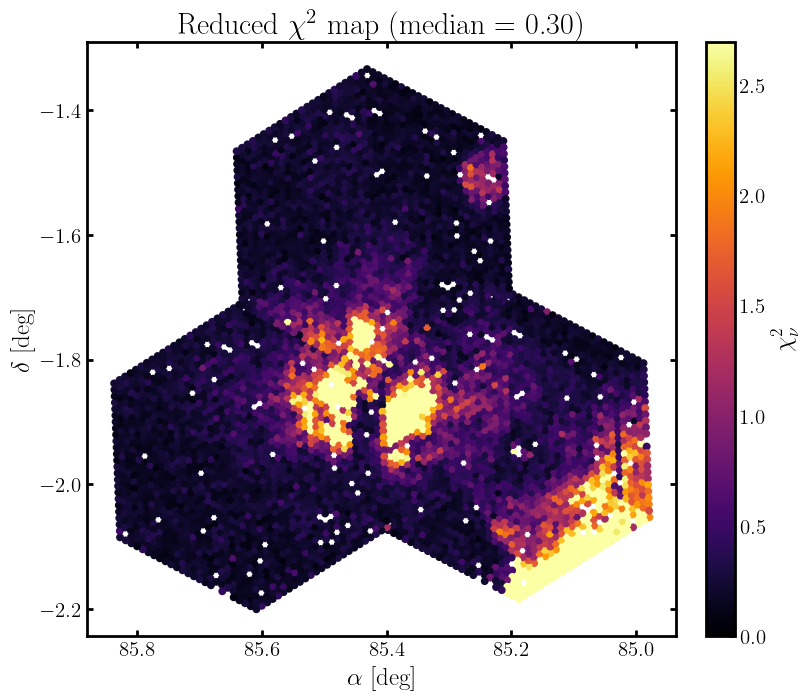

In [14]:
# Compute residuals and chi2
masked_data = np.where(fd.mask, fd.flux, np.nan)
masked_pred = np.where(fd.mask, pred_data, np.nan)
residuals = masked_data - masked_pred
norm_residuals = residuals / np.where(fd.mask, fd.u_flux, np.nan)
chi2 = norm_residuals**2

n_λ_per_spax = np.sum(fd.mask, axis=0)
chi2_per_spax = np.nansum(chi2, axis=0)
red_chi2 = chi2_per_spax / n_λ_per_spax

valid = np.isfinite(red_chi2) & (n_λ_per_spax > 0)
vmax = np.nanpercentile(red_chi2[valid], 95)

fig, ax = plt.subplots(figsize=(8, 7), dpi=100, layout="compressed")
sc = ax.scatter(
    fd.predict_α(fd.α)[valid],
    fd.predict_δ(fd.δ)[valid],
    c=red_chi2[valid],
    cmap="inferno",
    s=32,
    edgecolor="none",
    vmin=0,
    vmax=vmax,
)
ax.set_xlim(ax.get_xlim()[::-1])
ax.set_aspect("equal")
ax.set_xlabel(r"$\alpha$ [deg]")
ax.set_ylabel(r"$\delta$ [deg]")
fig.colorbar(sc, ax=ax, label=r"$\chi^2_\nu$")
ax.set_title(f"Reduced $\\chi^2$ map (median = {np.nanmedian(red_chi2[valid]):.2f})")
plt.show()

## Reduced $\chi^2$ spectrum

Reduced $\chi^2$ as a function of wavelength. Peaks reveal wavelengths where the model systematically struggles.

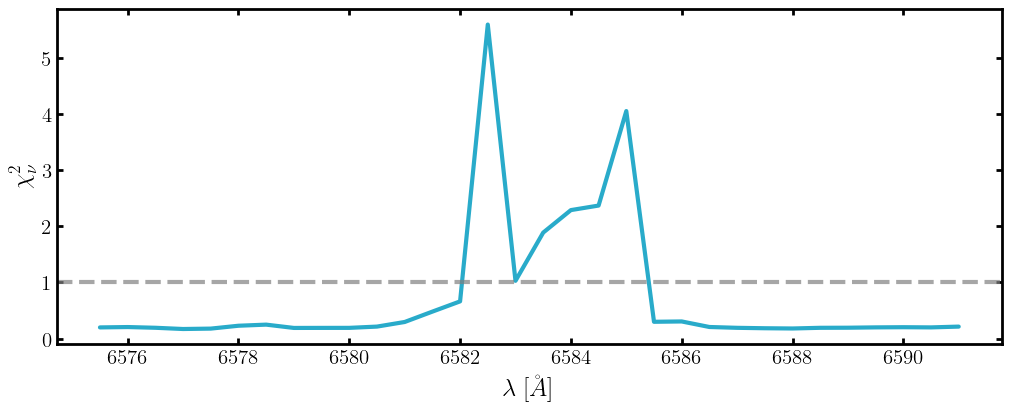

In [8]:
n_spax_per_λ = np.sum(fd.mask, axis=1)
chi2_per_λ = np.nansum(chi2, axis=1) / n_spax_per_λ

fig, ax = plt.subplots(figsize=(10, 4), dpi=100, layout="compressed")
ax.plot(fd.λ, chi2_per_λ)
ax.axhline(1.0, ls="--", c="grey", alpha=0.7)
ax.set_xlabel(r"$\lambda$ [$\AA$]")
ax.set_ylabel(r"$\chi^2_\nu$")
plt.show()

## Summed residuals map

Summed residuals per spaxel. Symmetric around zero for a good fit; persistent red or blue patches indicate systematic over/under-prediction.

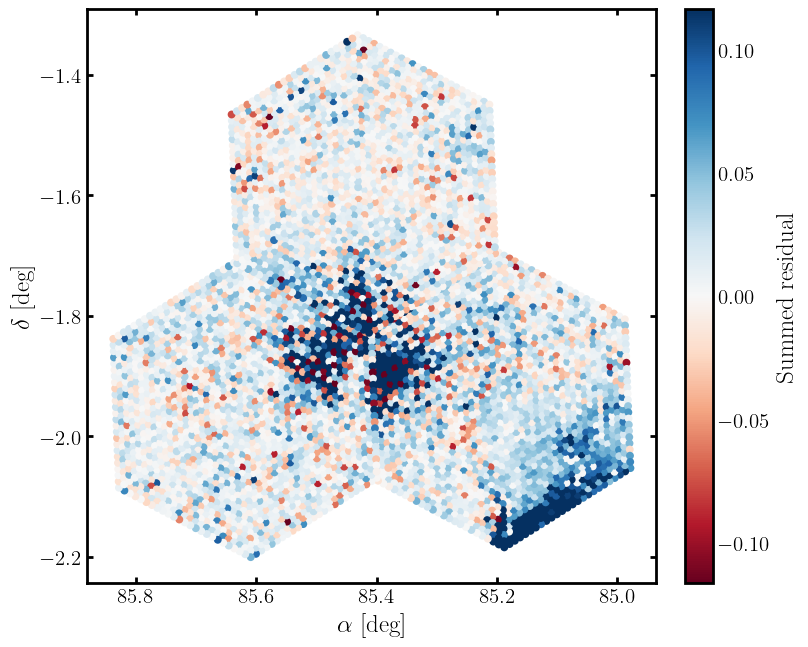

In [9]:
summed_resid = np.nansum(residuals, axis=0)
valid_r = np.isfinite(summed_resid)
vmax_r = np.nanpercentile(np.abs(summed_resid[valid_r]), 95)

fig, ax = plt.subplots(figsize=(8, 7), dpi=100, layout="compressed")
sc = ax.scatter(
    fd.predict_α(fd.α)[valid_r],
    fd.predict_δ(fd.δ)[valid_r],
    c=summed_resid[valid_r],
    cmap="RdBu",
    s=32,
    edgecolor="none",
    vmin=-vmax_r,
    vmax=vmax_r,
)
ax.set_xlim(ax.get_xlim()[::-1])
ax.set_aspect("equal")
ax.set_xlabel(r"$\alpha$ [deg]")
ax.set_ylabel(r"$\delta$ [deg]")
fig.colorbar(sc, ax=ax, label="Summed residual")
plt.show()

## Normalised residual histogram

Should follow $\mathcal{N}(0,1)$ for a well-calibrated fit. A wider distribution ($\sigma > 1$) suggests underestimated uncertainties or unmodelled structure; a narrower one ($\sigma < 1$) suggests overestimated uncertainties (common with DRP error spectra). In practice you often see both: a core narrower than $\mathcal{N}(0,1)$ but with heavy tails from outlier spaxels, which can pull the overall $\sigma$ above 1 even when the bulk of the distribution looks too narrow.

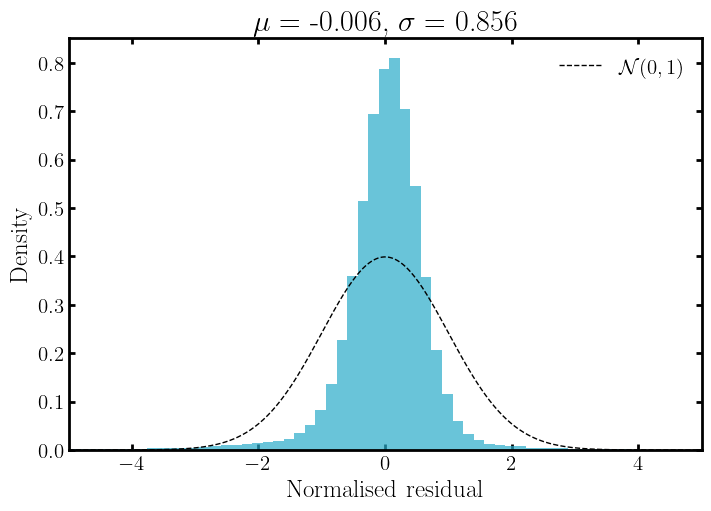

In [ ]:
flat = norm_residuals.ravel()
flat = flat[np.isfinite(flat)]

fig, ax = plt.subplots(figsize=(7, 5), dpi=100, layout="compressed")
ax.hist(flat, bins=200, density=True, histtype="stepfilled", alpha=0.7, color="C0")
x = np.linspace(-5, 5, 300)
ax.plot(
    x,
    np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi),
    "k--",
    lw=1,
    label=r"$\mathcal{N}(0,1)$",
)
ax.set_xlim(-5, 5)
ax.set_xlabel("Normalised residual")
ax.set_ylabel("Density")
ax.legend()
mu, sigma = np.mean(flat), np.std(flat)
ax.set_title(f"$\\mu$ = {mu:.3f}, $\\sigma$ = {sigma:.3f}")
plt.show()

## Worst-fit spaxels

Data vs model for spaxels sampled from the worst 10% by reduced $\chi^2$. Useful for identifying failure modes.

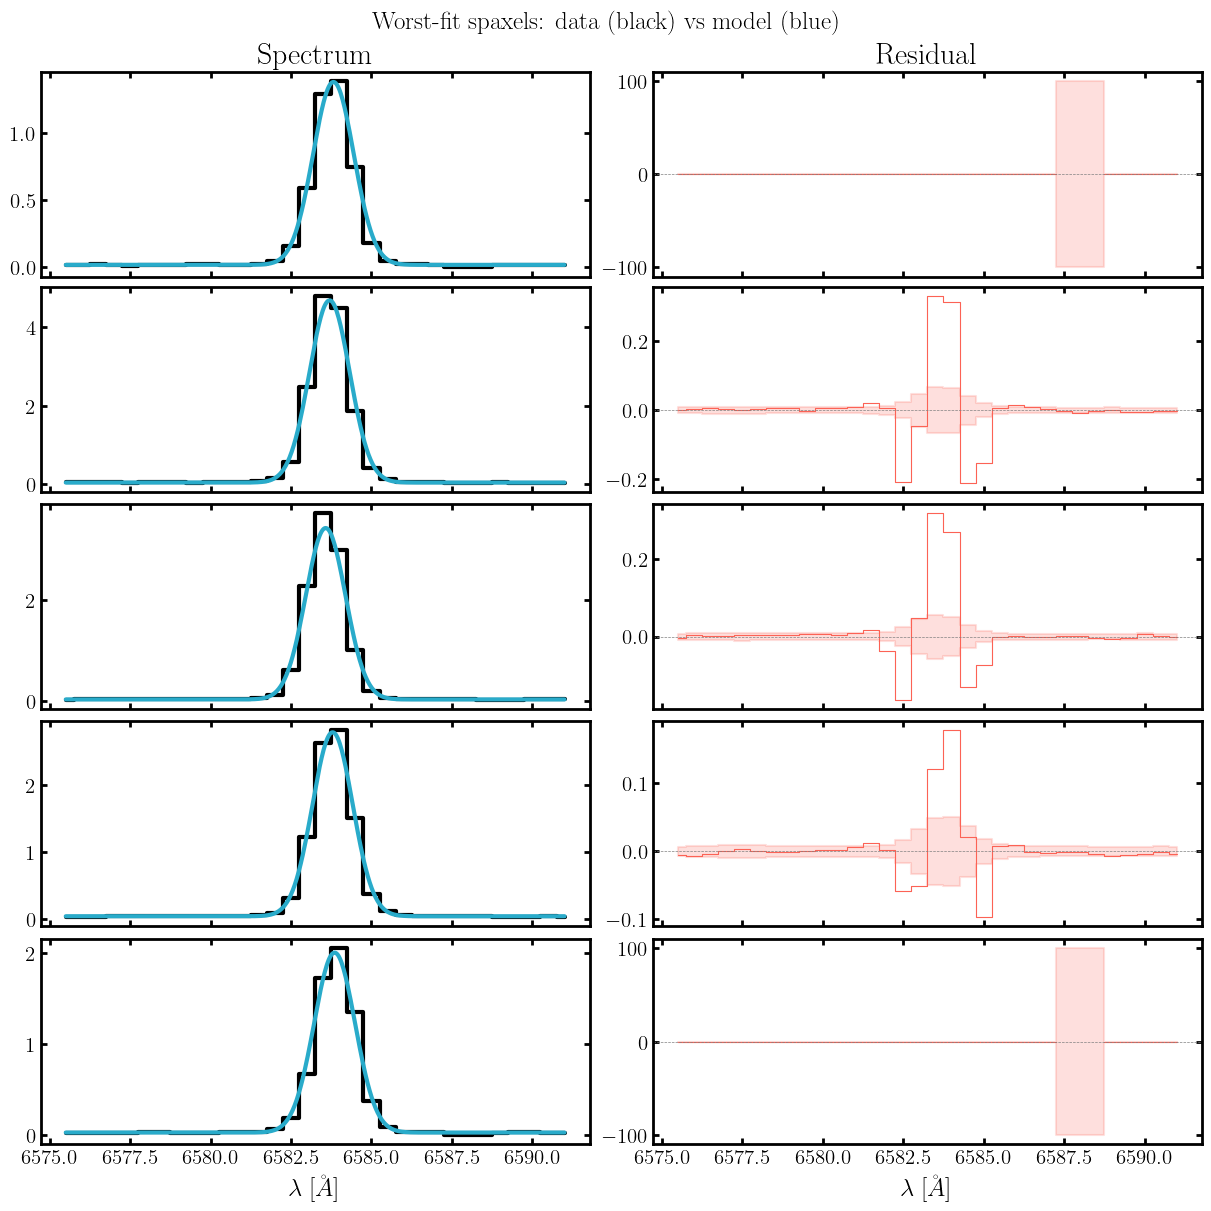

In [11]:
# Pick 10 spaxels from the worst 10%
valid_idx = np.where(valid)[0]
threshold = np.percentile(red_chi2[valid_idx], 90)
worst_pool = valid_idx[red_chi2[valid_idx] >= threshold]
worst_inds = rng.choice(worst_pool, size=min(10, len(worst_pool)), replace=False)

fig, axes = plt.subplots(5, 2, figsize=(12, 12), sharex=True, layout="compressed")
fig.suptitle("Worst-fit spaxels: data (black) vs model (blue)")
for i, ax_row in enumerate(axes):
    si = worst_inds[i]
    ax_row[0].step(fd.λ, fd.flux[:, si], c="k", where="mid", zorder=-2)
    ax_row[0].plot(λ_dense, pred_λ_dense[:, si], c="C0")
    ax_row[1].step(fd.λ, residuals[:, si], c="C3", where="mid", lw=0.8)
    ax_row[1].fill_between(
        fd.λ, -fd.u_flux[:, si], fd.u_flux[:, si], alpha=0.2, color="C3", step="mid"
    )
    ax_row[1].axhline(0, ls="--", c="grey", lw=0.5)
axes[0, 0].set_title("Spectrum")
axes[0, 1].set_title("Residual")
axes[-1, 0].set_xlabel(r"$\lambda$ [$\AA$]")
axes[-1, 1].set_xlabel(r"$\lambda$ [$\AA$]")
plt.show()

Clearly the line has plenty of non-Gaussianity in this example.